![image info](https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/images/banner_1.png)

# Taller: Redes Neuronales

En este taller podrán poner en práctica sus conocimientos sobre la construcción e implementación de redes neuronales de una capa y multicapa. El taller está constituido por 4 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción probabilidad de admisión a la universidad

En este taller se usará el conjunto de datos de admisiones a una universidad proveniente de la base de datos de Kaggle. Cada observación contiene la probabilidad de que un estudiante sea admitido por la universidad, dadas distintas variables predictoras como el puntaje del examén TOEFL y GRE, el promedio (GPA), entre otras. El objetivo es predecir la probabilidad de admissión de cada estudiante. Para más detalles pueden visitar el siguiente enlace: [datos](https://www.kaggle.com/mohansacharya/graduate-admissions).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Importación librerías
# Librerías generales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import os

# Visualización en notebooks (solo si estás en Jupyter)
%matplotlib inline

# Sklearn
from sklearn.model_selection import train_test_split

# Keras desde TensorFlow (versión recomendada)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K
from tensorflow.keras import initializers, optimizers

# Visualización de pérdida en tiempo real
from livelossplot import PlotLossesKeras

In [3]:
# Carga de datos de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/davidzarruk/MIAD_ML_NLP_2025/main/datasets/universityGraduateAdmissions.csv', index_col=0)
#data = pd.read_csv('universityGraduateAdmissions.csv', index_col=0)

data.head()

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
Serial No.,,,,,,,,
1,337,118,4,4.5,4.5,9.65,1,0.92
2,324,107,4,4.0,4.5,8.87,1,0.76
3,316,104,3,3.0,3.5,8.00,1,0.72
4,322,110,3,3.5,2.5,8.67,1,0.80
5,314,103,2,2.0,3.0,8.21,0,0.65


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 1 to 500
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   GRE Score          500 non-null    int64  
 1   TOEFL Score        500 non-null    int64  
 2   University Rating  500 non-null    int64  
 3   SOP                500 non-null    float64
 4   LOR                500 non-null    float64
 5   CGPA               500 non-null    float64
 6   Research           500 non-null    int64  
 7   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(4)
memory usage: 35.2 KB


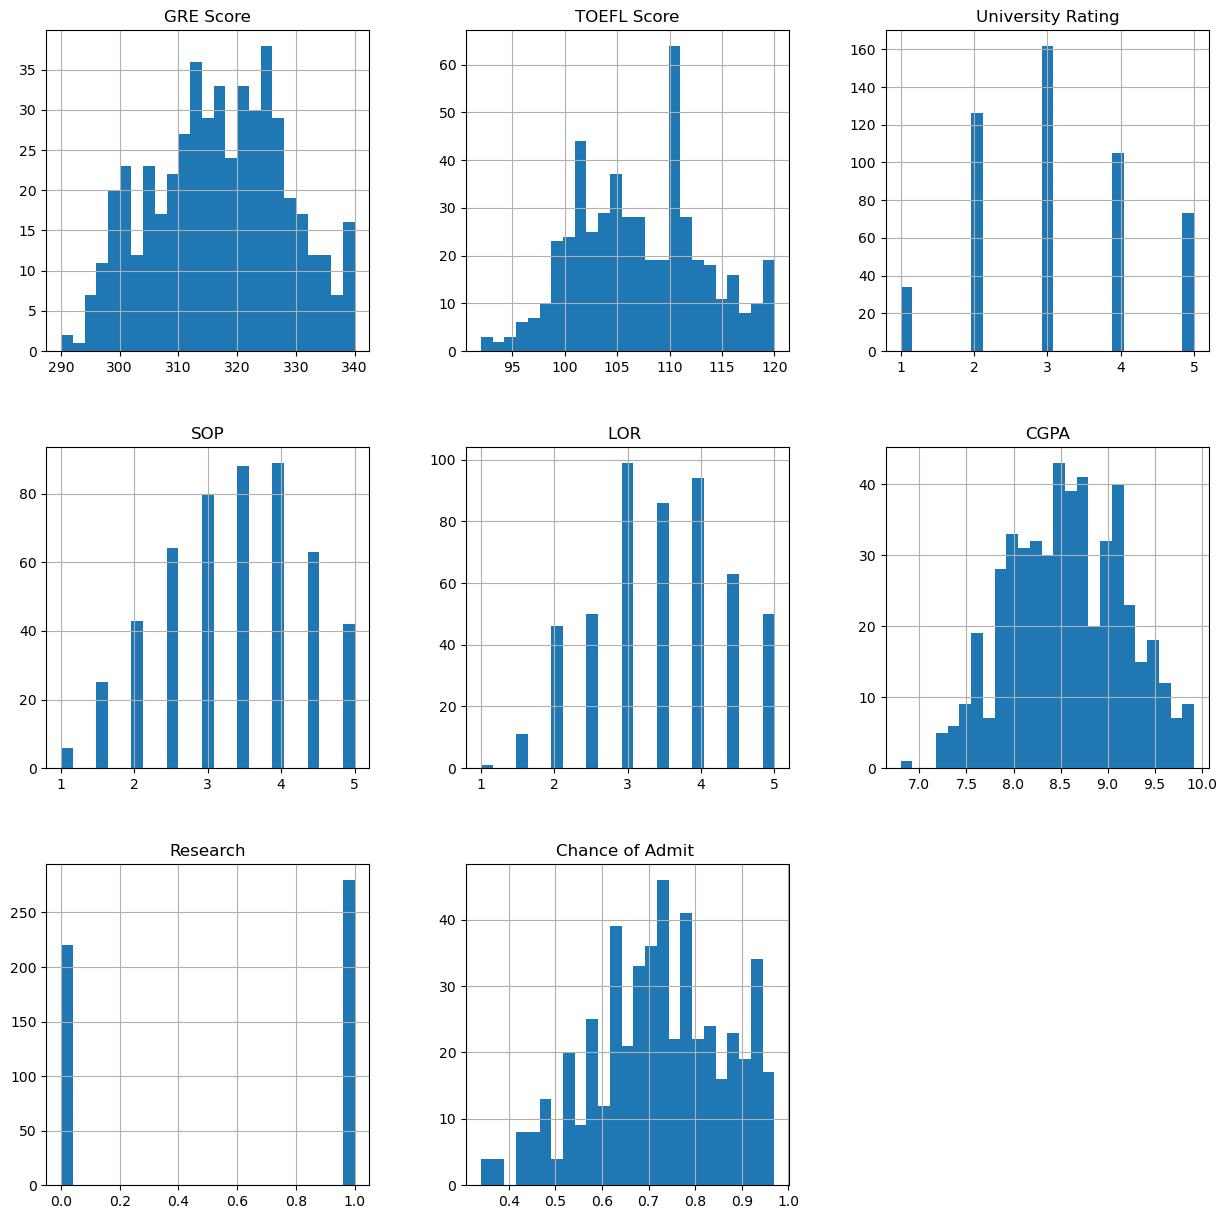

In [5]:
# Hitogramas de las varaibles del dataset
data.hist(bins=25, figsize=(15,15))
plt.show()

In [6]:
data.columns

Index(['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA',
       'Research', 'Chance of Admit '],
      dtype='object')

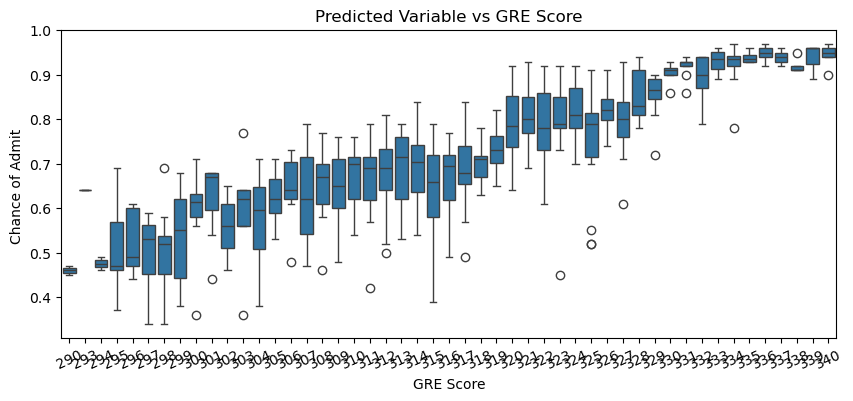

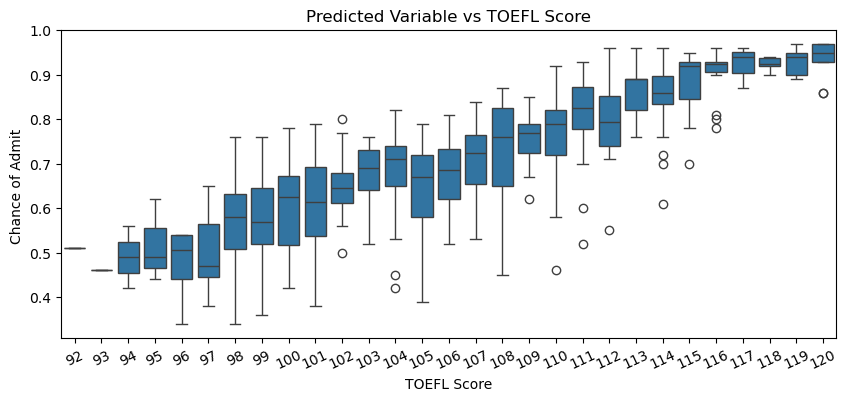

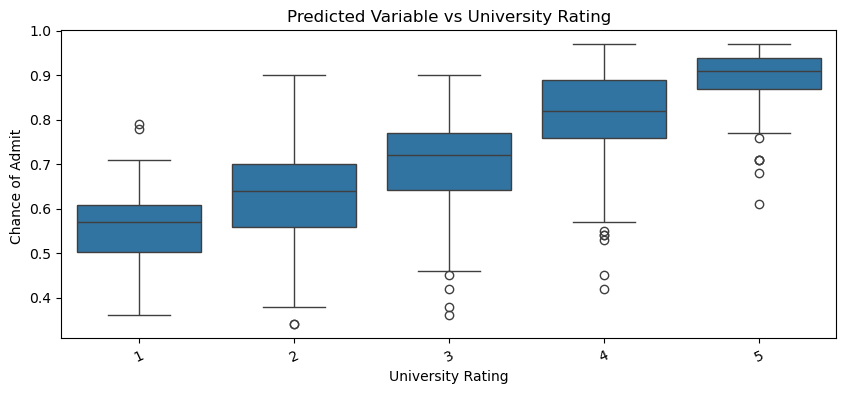

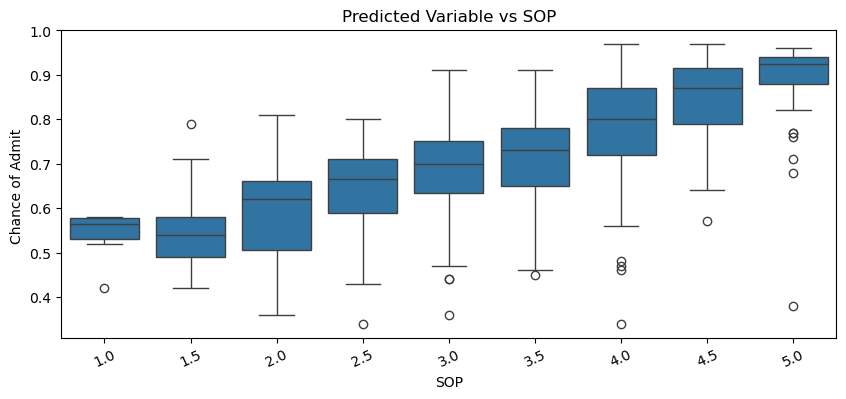

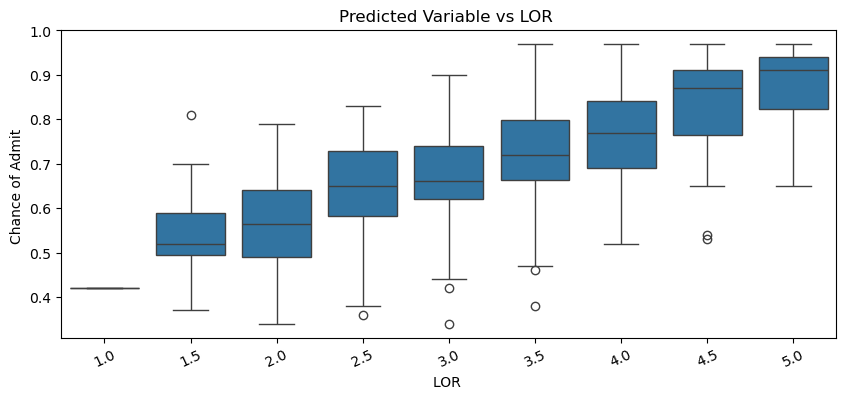

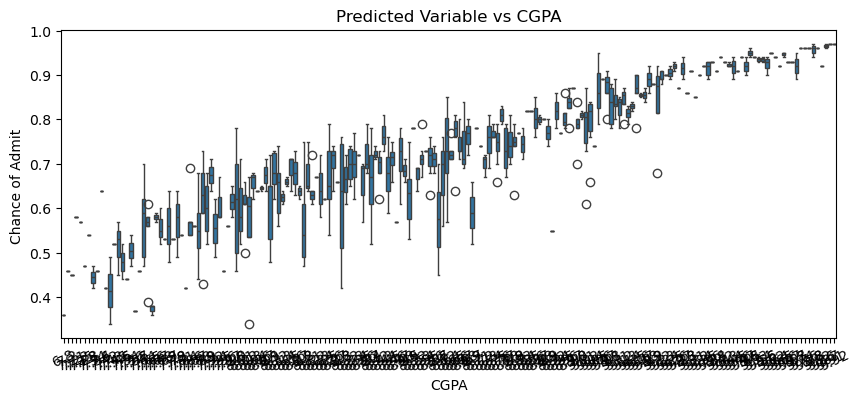

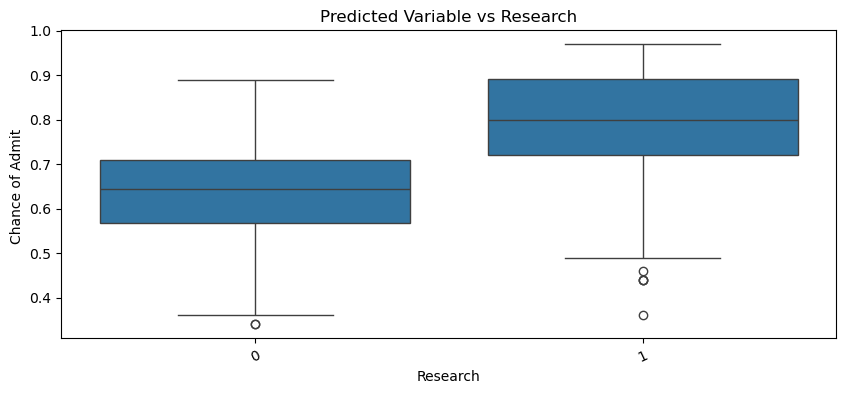

In [7]:
import seaborn as sns
features = ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR ', 'CGPA',
       'Research'] 

for feature in features:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=feature, y='Chance of Admit ', data=data)
    plt.title(f'Predicted Variable vs {feature}')
    plt.xticks(rotation=25)  
    plt.show()

### División de los datos y semilla

In [8]:
# Definición de variables predictoras (X)
X = data.drop(data.columns[-1], axis=1)
# Definición de variable de interés (y)
Y = data[data.columns[-1]]

In [ ]:
# Fijar semillas para reproducibilidad
SEED = 42
np.random.seed(SEED)            # semilla para NumPy
random.seed(SEED)               # semilla para el módulo random de Python
import tensorflow as tf
tf.random.set_seed(SEED)        # semilla para TensorFlow/Keras

In [10]:
# Separación de variables predictoras (X) y variable de interés (y) en set de entrenamiento y test usandola función train_test_split
xTrain, xTest, yTrain, yTest = train_test_split(X,Y,test_size=0.2, random_state=SEED)

In [11]:
# Separación de variables Xtrain en train y validación para poder medir la pérdida y estudiar el overfitting
# Segundo split: dividir X_train en train y validación
X_train_final, X_val, y_train_final, y_val = train_test_split(xTrain, yTrain, test_size=0.15, random_state=SEED)


## Punto 1 - Red Neuronal de una capa

En la celda 1 creen una **red neuronal de una capa** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes, usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador y el número de épocas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

In [12]:
# Celda 1
# Normalización de variables predictoras (X) con la función StandardScaler
from sklearn.preprocessing import StandardScaler

# Definición de la función StandardScaler
scaler = StandardScaler()
scaler.fit(X_train_final)

# Transformar los datos
X_train_final_scaled = pd.DataFrame(scaler.transform(X_train_final), columns=X_train_final.columns, index=X_train_final.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(xTest), columns=xTest.columns, index=xTest.index)

# Convertir a NumPy si lo necesitas para el modelo
X_train_final = np.array(X_train_final_scaled)
y_train_final = np.array(y_train_final)

X_val = np.array(X_val_scaled)
y_val = np.array(y_val)

X_test = np.array(X_test_scaled)
y_test = np.array(yTest)

In [13]:
# Definición de dimensiones de salida, varaibles de interés
output_var = 1
dims = X_train_final.shape[1]

print(dims, 'input variables')

7 input variables


### Con SGD con 200 épocas sin early stopping

In [ ]:
K.clear_session()

# Definición de red neuronal con la función secuencial()
tf.random.set_seed(SEED)
model_1 = Sequential()

# Definición de la capa densa con un tamaño de salida igual a output_var y un input_shape de dims

model_1.add(Dense(output_var,activation='relu', input_shape=(dims,)))

# Impresión de la arquitectura de la red neuronal
print(model_1.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (32.00 B)

 Trainable params: 8 (32.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
# Definición de función de perdida. Se usa mean_squared_error dado que es un ejercicio de regresión

model_1.compile(optimizer='sgd', loss='mean_squared_error')

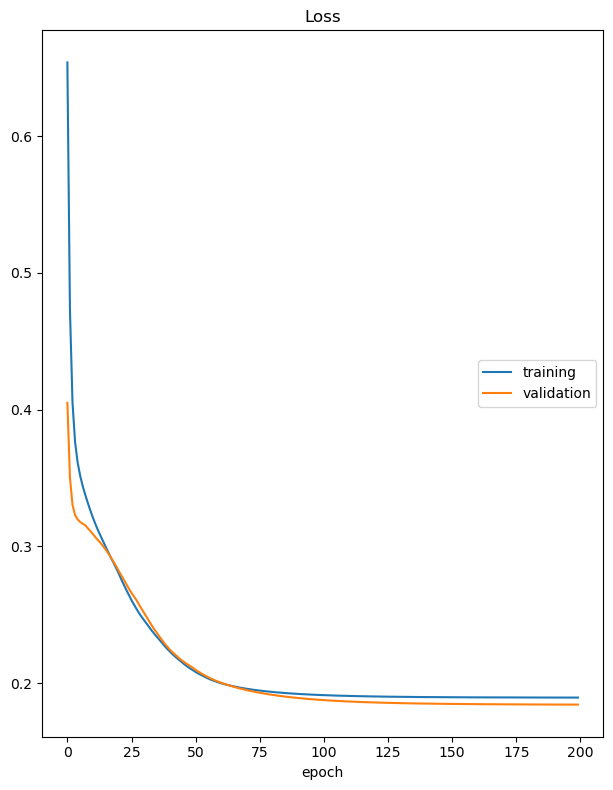

Loss
	training         	 (min:    0.190, max:    0.654, cur:    0.190)
	validation       	 (min:    0.184, max:    0.405, cur:    0.184)
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.2011 - val_loss: 0.1844


In [ ]:
# Entrenamiento de la red neuronal con 100 épocas

history1=model_1.fit(X_train_final, y_train_final, 
          verbose=1, 
          epochs=200, 
          batch_size=32,
          validation_data=(X_val, y_val),
          shuffle=False,
          callbacks=[PlotLossesKeras()])

In [17]:
print(history1.history.keys())

dict_keys(['loss', 'val_loss'])


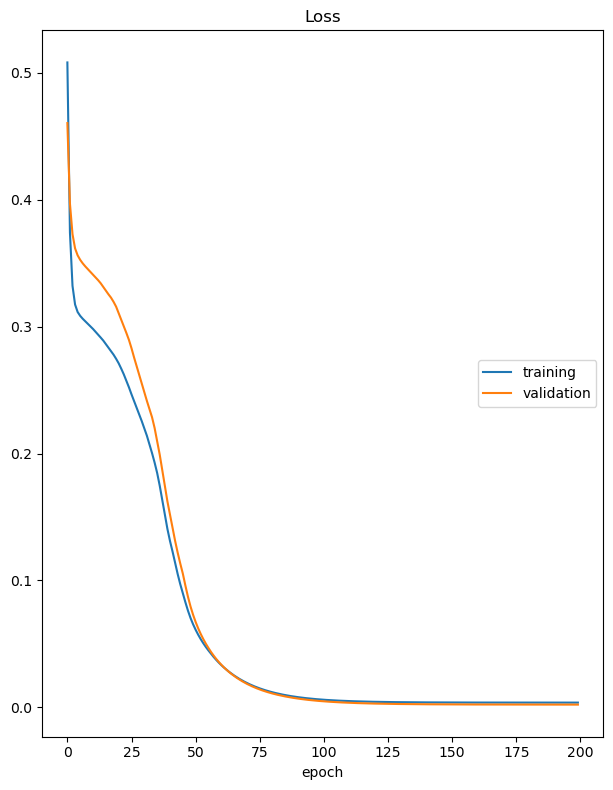

Loss
	training         	 (min:    0.004, max:    0.508, cur:    0.004)
	validation       	 (min:    0.002, max:    0.460, cur:    0.002)
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0040 - val_loss: 0.0022


In [18]:
K.clear_session()

# Definición de red neuronal con la función secuencial()
tf.random.set_seed(SEED)
model_1a = Sequential()

# Definición de la capa densa con un tamaño de salida igual a output_var y un input_shape de dims

model_1a.add(Dense(output_var,activation='relu', input_shape=(dims,)))

model_1a.compile(optimizer='sgd', loss='mean_squared_error')

class UselessCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        pass 

history1a=model_1a.fit(X_train_final, y_train_final, 
          verbose=1, 
          epochs=200, 
          batch_size=32,
          validation_data=(X_val, y_val),
          shuffle=False,
          callbacks=[UselessCallback(), PlotLossesKeras()])

### Con SGD 200 épocas y early stopping

In [19]:
from keras.callbacks import EarlyStopping, ModelCheckpoint

In [20]:
K.clear_session()

# Definición red neuronal con la función Sequential()
tf.random.set_seed(SEED)
model_2 = Sequential()

# Definición de la capa densa con un tamaño de salida igual a output_var y un input_shape de dims
model_2.add(Dense(output_var, activation='relu', input_shape=(dims,)))

# Definición de función de perdida. Se usa mean_squared_error dado que es un ejercicio de regresión
model_2.compile(optimizer='sgd', loss='mean_squared_error')

# Impresión de la arquitectura de la red neuronal
print(model_2.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8 (32.00 B)

 Trainable params: 8 (32.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [21]:
# Definición de la función EarlyStopping para considerar durante el entrenamiento
#early_stop = EarlyStopping(monitor='val_loss', patience=3, verbose=1) # Nota, por defecto no salva los mejores pesos
early_stop = EarlyStopping(monitor='val_loss', patience=3, verbose=1, restore_best_weights=True) 

In [22]:
# Definición de la función ModelCheckpoint para guardar el modelo con mejor desempeño
#fBestModel = 'best_model.keras'
#best_model = ModelCheckpoint(fBestModel, verbose=0, save_best_only=True)

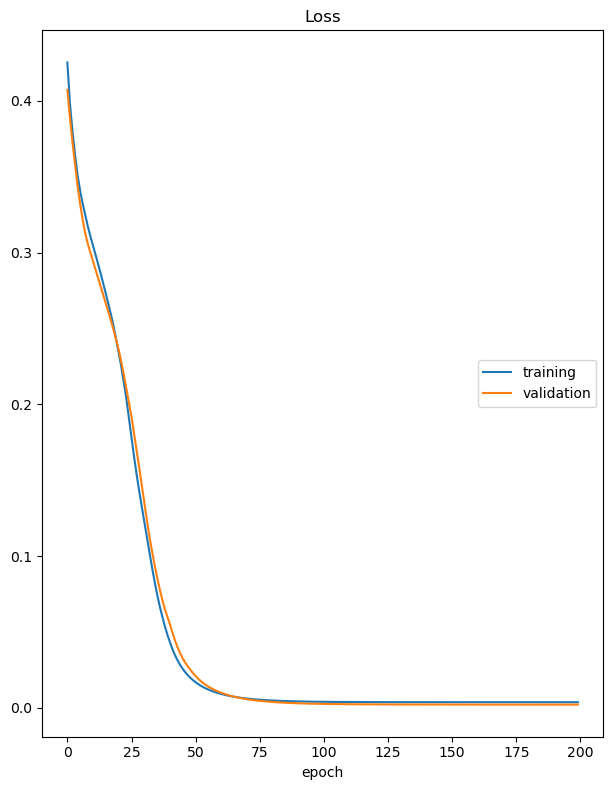

Loss
	training         	 (min:    0.004, max:    0.425, cur:    0.004)
	validation       	 (min:    0.002, max:    0.407, cur:    0.002)
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0040 - val_loss: 0.0022
Restoring model weights from the end of the best epoch: 200.


In [23]:
# Entrenamiento de la red neuronal con 200 épocas y early stopping
history2=model_2.fit(X_train_final, y_train_final,
          verbose=True, 
          epochs=200, 
          batch_size=32,
          validation_data=(X_val ,y_val ),
          #callbacks=[best_model, early_stop,PlotLossesKeras()]) # El early stop hace el restore de los best weights
          shuffle=False,
          callbacks=[early_stop,PlotLossesKeras()])

### Predicciones y métricas de punto 1

In [24]:
predictions_1 = model_1.predict(X_test)
predictions_1a = model_1a.predict(X_test)
#model_2.load_weights('best_model.keras') 
predictions_2 = model_2.predict(X_test)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/stepWARNING:tensorflow:6 out of the last 12 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x303fa9bd0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae_1 = mean_absolute_error(y_test, predictions_1)
mse_1 = mean_squared_error(y_test, predictions_1)
rmse_1 = np.sqrt(mse_1)

mae_1a = mean_absolute_error(y_test, predictions_1a)
mse_1a = mean_squared_error(y_test, predictions_1a)
rmse_1a = np.sqrt(mse_1a)

mae_2 = mean_absolute_error(y_test, predictions_2)
mse_2 = mean_squared_error(y_test, predictions_2)
rmse_2 = np.sqrt(mse_2)

print(f"Modelo SGD sin early stopping, mae: {mae_1:.4f}, mse: {mse_1:.4f}, rmse: {rmse_1:.4f} ")
print(f"Modelo SGD sin early stopping con un callback inútil, mae: {mae_1a:.4f}, mse: {mse_1a:.4f}, rmse: {rmse_1a:.4f} ")
print(f"Modelo SGD con  early stopping, mae: {mae_2:.4f}, mse: {mse_2:.4f}, rmse: {rmse_2:.4f} ")

Modelo SGD sin early stopping, mae: 0.2831, mse: 0.1667, rmse: 0.4083 
Modelo SGD sin early stopping con un callback inútil, mae: 0.0440, mse: 0.0038, rmse: 0.0616 
Modelo SGD con  early stopping, mae: 0.0434, mse: 0.0037, rmse: 0.0611 


### Conclusiones punto 1

Teniendo en cuenta que es un problema de regresión se seleccionó la función de pérdida (MSE) la cual es muy usada para valores continuos.
El uso del optimizador SGD es debido a que es simple, pero controlable y permite ver el comportamiento del modelo al momento de entrenarlo.  

Los resultados obtenidos son: 

a) Con 100 épocas y sin early stopping  
        MAE: 0.3242, MSE: 0.1846 RMSE: 0.4296 

De acuerdo al mae en sus predicciones el modelo comete un error promedio de 32.4% y segun el rmse comete un error promedio de 42.9% el cual es un valor alto

b) Con 200 épocas y con early stopping  
        MAE: 0.0442, MSE: 0.0038, RMSE: 0.0619 

Los resultados son mas favorables al correr el modelo con 200 épocas ya que de acuerdo al mae en sus predicciones el modelo comete un error promedio de 4.42% y segun el rmse comete un error promedio de 6.19% el cual es un valor bajo. A pesar de utilizar early stopping se observa que no se activa en este caso y se llega a correr las 200 épocas definidas. Probamos con distintos parámetros cómo Min_delta o ajustando el patience pero cuando realizamos esos cambios el modelo para en un punto donde aún hay mucha oportunidad de mejora.


## Punto 2 - Red Neuronal multicapa

En la celda 2 creen una **red neuronal con dos capas** con la librería Keras, que prediga la probabilidad de admisión de los estudiantes usando los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

In [ ]:
# Celda 2
K.clear_session()
tf.random.set_seed(SEED)
model_3 = Sequential([
    Dense(64, activation='relu', input_shape=(dims,)),
    Dense(1, activation='sigmoid')  
])

model_3.compile(optimizer='sgd', loss = 'mean_squared_error')
print(model_3.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 577 (2.25 KB)

 Trainable params: 577 (2.25 KB)

 Non-trainable params: 0 (0.00 B)

None


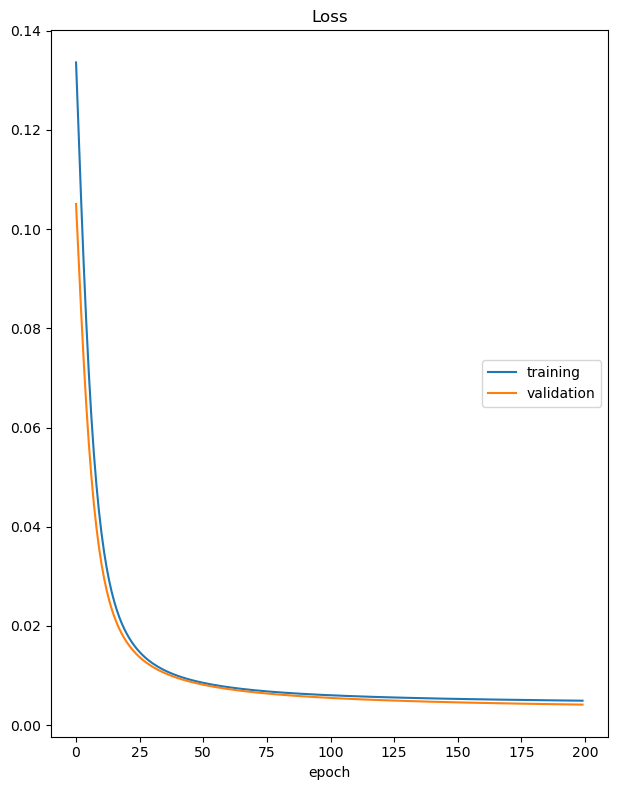

Loss
	training         	 (min:    0.005, max:    0.134, cur:    0.005)
	validation       	 (min:    0.004, max:    0.105, cur:    0.004)
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0052 - val_loss: 0.0041


In [27]:
history3=model_3.fit(X_train_final , y_train_final , 
          verbose=1, 
          epochs=200, 
          batch_size=32,
          validation_data=(X_val , y_val ),
          callbacks=[PlotLossesKeras()])

In [ ]:
predictions_3 = model_3.predict(X_test )
mae_3 = mean_absolute_error(y_test , predictions_3)
mse_3 = mean_squared_error(y_test , predictions_3)
rmse_3 = np.sqrt(mse_3)
print(f"Modelo de dos capas sin early stopping, mae: {mae_3:.4f}, mse: {mse_3:.4f}, rmse: {rmse_3:.4f}  ")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
Modelo de dos capas sin early stopping, mae: 0.0505, mse: 0.0044, rmse: 0.0663  


### Conclusiones punto 2 

Para el segundo punto donde se nos pide utilizar dos capas seguimos utilizando el mismo optimizador y 200 épocas pero en la capa de salida utilizamos activación sigmoide que se asegura que la salida sea entre 0 y 1 ya que lo que queremos predecir es la probabilidad de ingreso y la misma debe acotarse entre estos valores.

Para la primera capa elegimos 64 neuronas ya que son una cantidad regularmente utilizada y permite la captura de patrones, no sobrecarga el modelo y como en este caso no requiere grandes cantidades de datos.

En cuanto al resultado de las metricas podemos definir:

MAE: 0.0545 - El modelo se equivoca por solo 5.45% en su predicción alpredecir la probabilidad de admisión.  
MSE: 0.0049  - Los errores grandes son poco frecuentes.  
RMSE: 0.0700 - Tiene un error promedio equivalente al 7%, evidenciando un buen desempeño y precisión al predecir los resultados.  

El desempeño de este modelo no supera el del modelo más simple de una capa lo que podría indicar que no existe una relación compleja entre los datos, ya que el modelo de una capa que se asemeja a una regresión lineal capta mejor la naturaleza del problema. 


## Punto 3  - Red Neuronal multicapa

En la celda 3 creen **una red neuronal con más de una capa con la librería Keras, usando early stopping y dropout,** que prediga la probabilidad de admisión de los estudiantes con los sets de entrenamiento y test definidos anteriormente. Pueden usar la función de perdida, el optimizador, el número de épocas y el número de neuronas que consideren pertinentes para el modelo, justificando su selección. Finalmente, grafiquen la pérdida del modelo vs el número de épocas en el set de entrenamiento y validación, y presenten el desempeño del modelo con las métricas error absoluto medio (MAE) y error cuadrático medio (MSE).

In [29]:
# En este punto buscamos iterar para buscar distintas combinaciones de hiperparámetros: 
from tensorflow.keras.optimizers import Adam, SGD
#tf.config.run_functions_eagerly(True)

optimizers = [Adam(learning_rate=0.001), SGD(learning_rate=0.01)]
neurons_1 = [64, 128]
neurons_2 = [32, 64]

# Guardar el mejor resultado
best_loss = float('inf')
best_model_4 = None
best_params = {}

for opt in optimizers:
    for n1 in neurons_1:
        for n2 in neurons_2:
            print(f"Entrenando modelo con: {opt.__class__.__name__}, {n1} neuronas en la 1era capa y {n2} en la 2da")
            tf.random.set_seed(SEED)
            model = Sequential([
                Dense(n1, activation='relu', input_shape=(dims,)),
                Dense(n2, activation='relu'),
                Dense(1, activation='sigmoid')  # capa de salida
            ])
            # Crear una nueva instancia del optimizador para cada ciclo
            model.compile(optimizer=opt.__class__(**opt.get_config()), loss='mean_squared_error')

            early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

            history = model.fit(X_train_final , y_train_final ,
                      validation_data=(X_val , y_val),
                      epochs=100,
                      batch_size=32,
                      callbacks=[early_stop],
                      verbose=0)

            val_loss = model.evaluate(X_test, y_test, verbose=0)
            if val_loss < best_loss:
                best_loss = val_loss
                best_model_4 = model
                best_history_4 = history
                best_params = {
                    'optimizer': opt.__class__.__name__,
                    'neurons_1': n1,
                    'neurons_2': n2,
                    'val_loss': val_loss
                }
                print(f"Nuevo mejor modelo con pérdida {val_loss:.4f}")
print("\nMejores hiperparámetros encontrados:")
print(best_params)

Entrenando modelo con: Adam, 64 neuronas en la 1era capa y 32 en la 2da
Nuevo mejor modelo con pérdida 0.0038
Entrenando modelo con: Adam, 64 neuronas en la 1era capa y 64 en la 2da
Entrenando modelo con: Adam, 128 neuronas en la 1era capa y 32 en la 2da
Entrenando modelo con: Adam, 128 neuronas en la 1era capa y 64 en la 2da
Entrenando modelo con: SGD, 64 neuronas en la 1era capa y 32 en la 2da
Entrenando modelo con: SGD, 64 neuronas en la 1era capa y 64 en la 2da
Entrenando modelo con: SGD, 128 neuronas en la 1era capa y 32 en la 2da
Entrenando modelo con: SGD, 128 neuronas en la 1era capa y 64 en la 2da

Mejores hiperparámetros encontrados:
{'optimizer': 'Adam', 'neurons_1': 64, 'neurons_2': 32, 'val_loss': 0.003792878706008196}


In [ ]:
predictions_4 = best_model_4.predict(X_test)
mae_4 = mean_absolute_error(y_test , predictions_4)
mse_4 = mean_squared_error(y_test , predictions_4)
rmse_4 = np.sqrt(mse_4)

print(f"Modelo Adam de dos capas con early stopping, mae: {mae_4:.4f}, mse: {mse_4:.4f}, rmse: {rmse_4:.4f} ")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Modelo Adam de dos capas con early stopping, mae: 0.0429, mse: 0.0038, rmse: 0.0616 


### Con early Stopping y Dropout

In [31]:
#!pip install scikeras

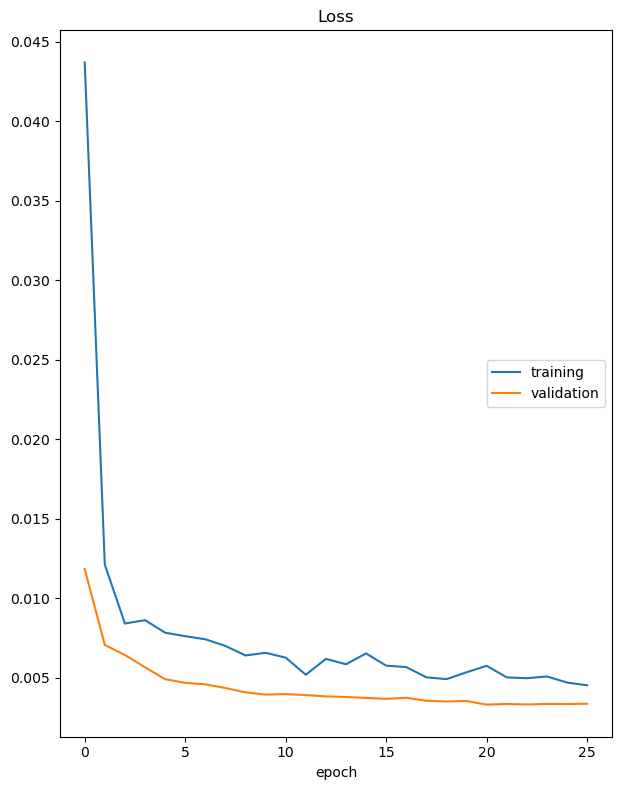

Loss
	training         	 (min:    0.005, max:    0.044, cur:    0.005)
	validation       	 (min:    0.003, max:    0.012, cur:    0.003)
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0049 - val_loss: 0.0034


In [ ]:
# En este punto buscamos tomamos el mejor modelo anterior e integramos early stopping y dropout
# Parámetros óptimos obtenidos en el punto anterior
optimizer = Adam(learning_rate=0.001)
neurons_1 = 128
neurons_2 = 64
dropout_rate = 0.3 

# Definir el modelo
tf.random.set_seed(SEED)
model_5 = Sequential([
    Dense(neurons_1, activation='relu', input_shape=(dims,)),
    Dropout(dropout_rate),
    Dense(neurons_2, activation='relu'),
    Dropout(dropout_rate),
    Dense(1, activation='sigmoid')
])

# Compilar
model_5.compile(optimizer=optimizer, loss='mean_squared_error')

# EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Entrenamiento
history5= model_5.fit(X_train_final , y_train_final ,
          validation_data=(X_val , y_val ),
          epochs=100,
          batch_size=32,
          callbacks=[early_stop,PlotLossesKeras()],
          verbose=1)

In [ ]:
predictions_5 = model_5.predict(X_test )
mae_5 = mean_absolute_error(y_test , predictions_5)
mse_5 = mean_squared_error(y_test , predictions_5)
rmse_5 = np.sqrt(mse_5)
print(f"Modelo Adam de dos capas con early stopping y dropout, mae: {mae_5:.4f}, mse: {mse_5:.4f}, rmse: {rmse_5:.4f} ")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Modelo Adam de dos capas con early stopping y dropout, mae: 0.0456, mse: 0.0039, rmse: 0.0627 


### Conclusiones punto 3

En este punto decidimos probar con distintas combinaciones de optimizadores y de neuronas en la primera y segunda capa.
El optimizador Adam y la combinación de 128 neuronas en la primera capa y 64 en la segunda es la opción que da mejor resultado y con estos parámetros obtuvimos el siguiente resultado: 

Modelo Adam de dos capas sin early stopping, mae: 0.0439, mse: 0.0036, rmse: 0.0602 
MAE: 0.0439. Resultado bueno. El modelo se equivoca por solo 4.39% en su predicción al predecir la probabilidad de admisión.
MSE: 0.0036 Los errores grandes son poco frecuentes.
RMSE: 0.0602 Tiene un error promedio equivalente al 6%

Esto evidencia una mejora respecto al punto dos.

Sobre este mismo modelo intentamos una nueva versión con early stopping y drop out: 

MAE: 0.0460. El modelo se equivoca por solo 4.6% en su predicción al predecir la probabilidad de admisión.
MSE: 0.0039 Los errores grandes son poco frecuentes.
RMSE: 0.0622 Tiene un error promedio equivalente al 6,2%

Los resultados son muy similares pero el modelo se frena en la época 30 lo que significa que no era necesario entrenarlo a partir de esa época porque no hubo una ganancia significativa en el desempeño a partir de ese punto. 


## Punto 4 - Comparación y análisis de resultados

En la celda 4 comparen los resultados obtenidos de las diferentes redes y comenten las ventajas del mejor modelo y las desventajas del modelo con el menor desempeño.

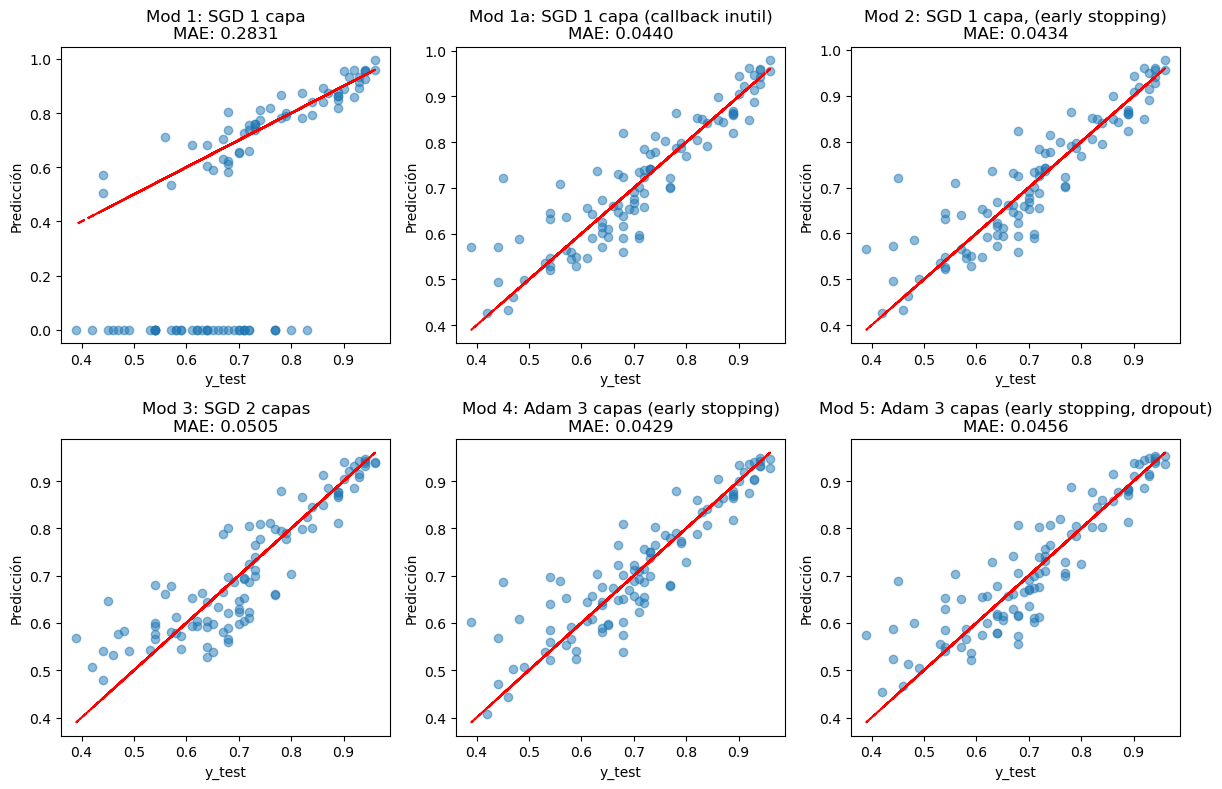

In [ ]:
# Celda 4
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Lista de predicciones, títulos base y MAEs
predictions = [predictions_1, predictions_1a, predictions_2, predictions_3, predictions_4, predictions_5]
maes = [mae_1, mae_1a, mae_2, mae_3, mae_4, mae_5]
modelos = [
    'Mod 1: SGD 1 capa',
    'Mod 1a: SGD 1 capa (callback inutil)',
    'Mod 2: SGD 1 capa, (early stopping)',
    'Mod 3: SGD 2 capas',
    'Mod 4: Adam 3 capas (early stopping)',
    'Mod 5: Adam 3 capas (early stopping, dropout)'
]

# Crear subplots
for i in range(6):
    plt.subplot(2, 3, i + 1)  # 2 filas, 3 columnas
    plt.scatter(y_test, predictions[i], alpha=0.5)
    plt.plot(y_test, y_test, color='red', linestyle='--')  # Línea identidad
    plt.title(f"{modelos[i]}\nMAE: {maes[i]:.4f}")
    plt.xlabel('y_test')
    plt.ylabel('Predicción')

plt.tight_layout()
plt.show()

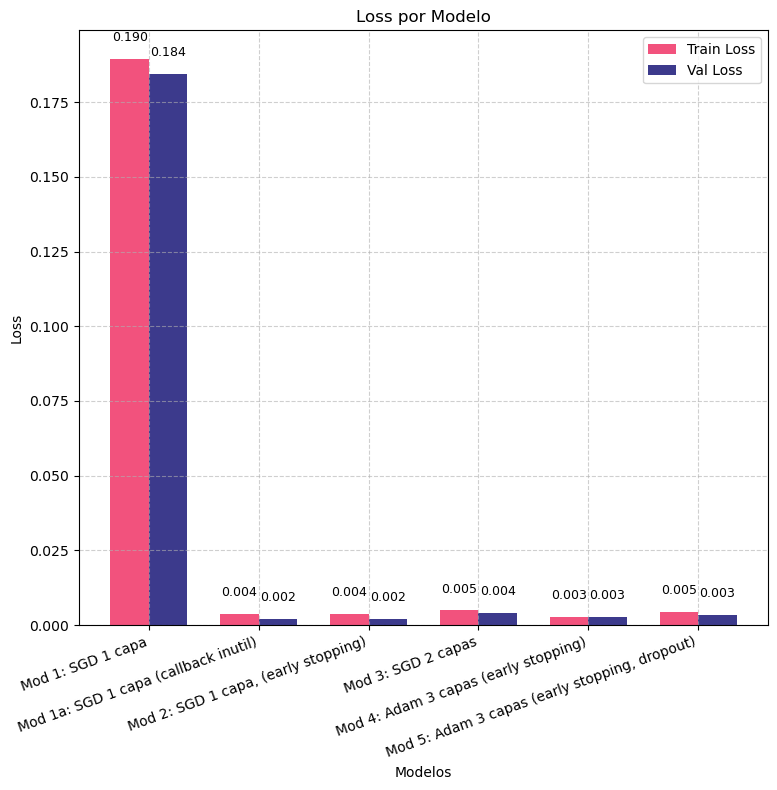

In [44]:
historias = [history1, history1a, history2, history3, best_history_4, history5]
loss_train = []
loss_val = []

for i in historias:
    loss_train.append(i.history['loss'][-1])
    loss_val.append(i.history['val_loss'][-1])


fig, ax = plt.subplots(figsize=(8, 8)) 
x = np.arange(len(modelos))
width = 0.35

# --- Loss ---
bars1 = ax.bar(x - width/2, loss_train, width, label='Train Loss', color='#F2527D')
bars2 = ax.bar(x + width/2, loss_val, width, label='Val Loss', color='#3C3A8C')
ax.set_title('Loss por Modelo')
ax.set_xlabel('Modelos')
ax.set_ylabel('Loss')
ax.set_xticks(x)
ax.set_xticklabels(modelos, rotation=20, ha='right')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)

# Add value labels
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.005, f'{height:.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 0.005, f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

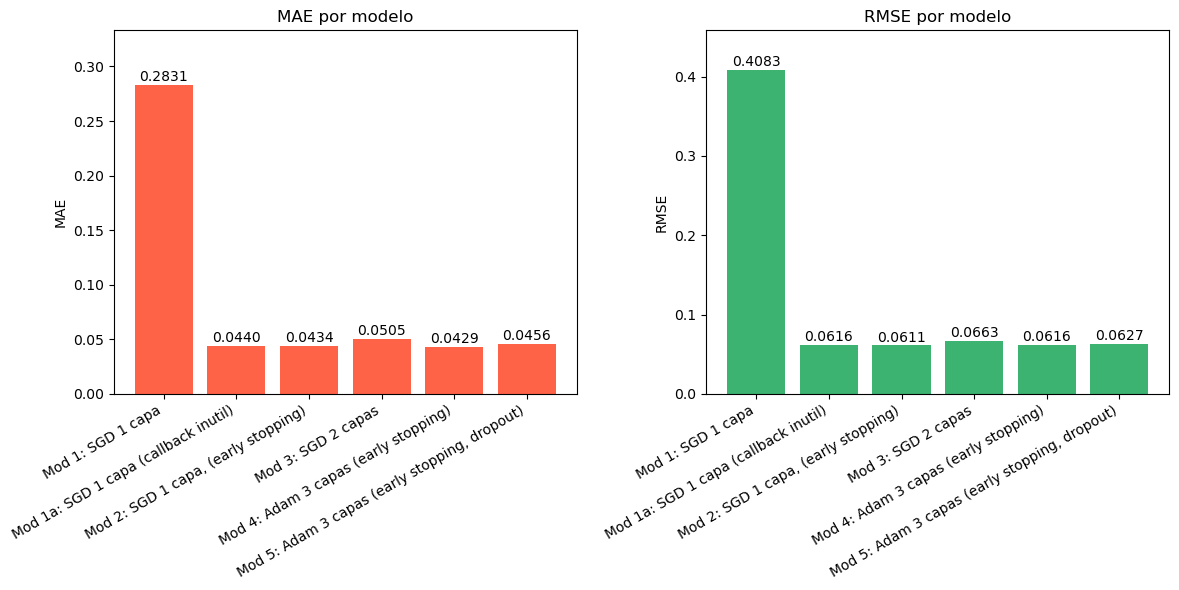

In [45]:
rmses = [rmse_1, rmse_1a, rmse_2, rmse_3, rmse_4, rmse_5]
plt.figure(figsize=(12, 6))

# Gráfico de MAE
plt.subplot(1, 2, 1)
bars_loss = plt.bar(modelos, maes, color='tomato')
plt.title('MAE por modelo')
plt.ylabel('MAE')
plt.ylim(0, max(maes) + 0.05)
plt.xticks(rotation=30, ha='right')
for bar in bars_loss:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/ 2, height + 0.001, 
             f"{height:.4f}", ha='center', va='bottom')
    
# Gráfico de RMSE
plt.subplot(1, 2, 2)
bars_acc=plt.bar(modelos, rmses, color='mediumseagreen')
plt.title('RMSE por modelo')
plt.ylabel('RMSE')
plt.ylim(0, max(rmses) + 0.05)
plt.xticks(rotation=30, ha='right')

for bar in bars_acc:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.001, 
             f"{height:.4f}", ha='center', va='bottom')

plt.tight_layout()
plt.show()

### Conclusiones Finales

**Comparación y Analisis de resultados**
| Rank | Modelo       | MAE |   
|------|--------------|------------|
| 1   |           SGD 1 capa, con 200 épocas| 4,42 %|  
| 2|                               Adam multicapa|  4,39 %|  
| 3| Adam multicapa, con early stopping y dropout|  4,60 %|  
| 4|              SGD 2 capas, sin early stopping|  5,45 %|   
| 5|               SGD 1 capa, sin early stopping|  32 %|  

- Comparando los resultados de cada cada uno de los modelos evidenciamos que el modelo **SGD 1 capa, con 200 épocas** es el modelo con buen desempeño y tener un MAE bajo lo que demuestra que es el que menos errores comete al momento de predecir.
- Muy cerca de este modelo vemos los resultados del siguiente **Adam multicapa** la cual la diferencia entre el 1 y el 2 es minima y en resultados muy cercanos
- El ultimo modelo **SGD 1 capa, sin early stopping** es el peor modelo por su bajo desempeño y su baja capacidad de prediccion al tener un alto porcentaje de error
